# Six-Company Robustness Notebook

This mini notebook builds a six-asset robustness dataset and three equally weighted bank-category indices, then runs descriptive statistics, unit-root tests, correlations, and TVP-VAR connectedness models.

The structure intentionally mirrors the relevant parts of `IndexCreation - REMASTERED.ipynb`, but keeps the workflow compact for the smaller robustness exercise.

## Important Data Notes

- Requested assets: `DAVE`, `MNLY`, `SOFI`, `NU`, `JPM`, `BAC`.
- Workbook assets used here: `DAVE`, `ML`, `SOFI`, `NU`, `JPM`, `WFC`.
- `ML` is used as the workbook ticker for MoneyLion in place of requested `MNLY`.
- `WFC` substitutes for missing `BAC` because `BAC` is not present in `All Bank Data.xlsx`.
- The professor's requested end date is `2026-03-03`, but this workbook currently ends on `2025-05-07`. The working end date is therefore set to `2025-05-07`.

When updated data are available, add/confirm `BAC`, extend the workbook through `2026-03-03`, replace `WFC` with `BAC` in `ASSET_MAP` and `INDEX_GROUPS`, then set `WORKING_END_DATE = "2026-03-03"`.

## 1. Setup

In [1]:
%load_ext rpy2.ipython

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:,.4f}".format

print("Python setup complete.")

Error importing in API mode: ImportError("dlopen(/Users/james/Documents/GitHub/FinanceResearch/.venv/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/james/Documents/GitHub/FinanceResearch/.venv/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


Python setup complete.


In [2]:
%%R

library(ConnectednessApproach)
library(vars)
library(zoo)

print("R setup complete.")
sessionInfo()

[1] "R setup complete."
R version 4.5.2 (2025-10-31)
Platform: aarch64-apple-darwin25.0.0
Running under: macOS Tahoe 26.5.1

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /opt/homebrew/Cellar/r/4.5.2_1/lib/R/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] C.UTF-8/C.UTF-8/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: America/Monterrey
tzcode source: internal

attached base packages:
[1] tools     stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] vars_1.6-1                  lmtest_0.9-40              
[3] urca_1.3-4                  strucchange_1.5-4          
[5] sandwich_3.1-1              zoo_1.8-14                 
[7] MASS_7.3-65                 ConnectednessApproach_1.0.4

loaded via a namespace (and not attached):
 [1] rmgarch_1.4-2                shape_1.4.6.1               
 [3] xfun_0.53                    ks_1.15.1 


Please cite as: 

 Gabauer, David (2022). ConnectednessApproach.
 R package version 1.0.0. https://CRAN.R-project.org/package=ConnectednessApproach 

Loading required package: MASS
Loading required package: strucchange
Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: sandwich
Loading required package: urca
Loading required package: lmtest

Attaching package: ‘vars’

The following object is masked from ‘package:ConnectednessApproach’:

    VAR



## 2. Configuration

In [3]:
DATA_FILE = Path("All Bank Data.xlsx")

REQUESTED_START_DATE = pd.Timestamp("2020-03-03")
REQUESTED_END_DATE = pd.Timestamp("2026-03-03")

# Current workbook maximum date is 2025-05-07.
# Later: set this back to "2026-03-03" once the workbook contains data through that date.
WORKING_END_DATE = pd.Timestamp("2025-05-07")

K = 100
RETURN_SCALE = 100
MIN_TVPVAR_OBS = 60

ASSET_MAP = pd.DataFrame(
    [
        {"Requested": "DAVE", "WorkbookTicker": "DAVE", "Sheet": "NeoBanks", "Group": "NeoBank", "Note": ""},
        {"Requested": "MNLY", "WorkbookTicker": "ML", "Sheet": "NeoBanks", "Group": "NeoBank", "Note": "Workbook ticker for MoneyLion"},
        {"Requested": "SOFI", "WorkbookTicker": "SOFI", "Sheet": "Challengers", "Group": "Challenger", "Note": ""},
        {"Requested": "NU", "WorkbookTicker": "NU", "Sheet": "Challengers", "Group": "Challenger", "Note": ""},
        {"Requested": "JPM", "WorkbookTicker": "JPM", "Sheet": "Traditionals", "Group": "Traditional", "Note": ""},
        {"Requested": "BAC", "WorkbookTicker": "WFC", "Sheet": "Traditionals", "Group": "Traditional", "Note": "Substitute because BAC is missing from workbook"},
    ]
)

INDEX_GROUPS = {
    "NeoBank": ["DAVE", "ML"],
    "Challenger": ["SOFI", "NU"],
    "Traditional": ["JPM", "WFC"],
}

PERIODS = {
    "1. COVID and SPAC boom": ("2020-03-03", "2021-12-31"),
    "2. Tightening and stress": ("2022-01-01", "2023-12-31"),
    "3. Recent period": ("2024-01-01", WORKING_END_DATE.strftime("%Y-%m-%d")),
}

display(ASSET_MAP)
print(f"Requested sample: {REQUESTED_START_DATE.date()} to {REQUESTED_END_DATE.date()}")
print(f"Working sample:   {REQUESTED_START_DATE.date()} to {WORKING_END_DATE.date()}")
print(f"Index rebasing factor K: {K}")

,Requested,WorkbookTicker,Sheet,Group,Note
0,DAVE,DAVE,NeoBanks,NeoBank,
1,MNLY,ML,NeoBanks,NeoBank,Workbook ticker for MoneyLion
2,SOFI,SOFI,Challengers,Challenger,
3,NU,NU,Challengers,Challenger,
4,JPM,JPM,Traditionals,Traditional,
5,BAC,WFC,Traditionals,Traditional,Substitute because BAC is missing from workbook


Requested sample: 2020-03-03 to 2026-03-03
Working sample:   2020-03-03 to 2025-05-07
Index rebasing factor K: 100


## 3. Load and Validate Prices

In [4]:
def load_sheet_prices(filepath: Path, sheet_name: str) -> pd.DataFrame:
    """Load repeated Exchange Date / ticker price pairs from one workbook sheet."""
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=0)
    company_frames = []

    for i in range(0, raw.shape[1], 2):
        if i + 1 >= raw.shape[1]:
            continue

        ticker = str(raw.columns[i + 1]).strip()
        frame = pd.DataFrame(
            {
                "Date": pd.to_datetime(raw.iloc[:, i], errors="coerce"),
                ticker: pd.to_numeric(raw.iloc[:, i + 1], errors="coerce"),
            }
        ).dropna(subset=["Date", ticker])

        if not frame.empty:
            frame = frame.set_index("Date").sort_index()
            company_frames.append(frame)

    if not company_frames:
        raise ValueError(f"No usable company price data found in sheet: {sheet_name}")

    return pd.concat(company_frames, axis=1).sort_index()


def ffill_inside_observed_range(prices: pd.DataFrame) -> pd.DataFrame:
    """Forward-fill internal missing prices without extending beyond each asset's last real observation."""
    filled = prices.copy()
    for col in filled.columns:
        valid = filled[col].dropna()
        if valid.empty:
            continue
        first, last = valid.index.min(), valid.index.max()
        outside = (filled.index < first) | (filled.index > last)
        filled.loc[~outside, col] = filled.loc[~outside, col].ffill()
        filled.loc[outside, col] = np.nan
    return filled


def build_asset_price_panel(filepath: Path, asset_map: pd.DataFrame) -> pd.DataFrame:
    if not filepath.exists():
        raise FileNotFoundError(f"Cannot find data workbook: {filepath.resolve()}")

    sheet_prices = {}
    for sheet_name in asset_map["Sheet"].unique():
        sheet_prices[sheet_name] = load_sheet_prices(filepath, sheet_name)

    missing = []
    selected = []
    for _, row in asset_map.iterrows():
        ticker = row["WorkbookTicker"]
        sheet_name = row["Sheet"]
        sheet_df = sheet_prices[sheet_name]
        if ticker not in sheet_df.columns:
            missing.append((ticker, sheet_name))
        else:
            selected.append(sheet_df[[ticker]])

    if missing:
        missing_text = ", ".join([f"{ticker} in {sheet}" for ticker, sheet in missing])
        raise KeyError(f"Missing required workbook tickers: {missing_text}")

    prices = pd.concat(selected, axis=1).sort_index()
    prices = prices.loc[REQUESTED_START_DATE:WORKING_END_DATE]
    prices = ffill_inside_observed_range(prices)
    return prices


asset_prices = build_asset_price_panel(DATA_FILE, ASSET_MAP)

availability = []
for col in asset_prices.columns:
    valid = asset_prices[col].dropna()
    availability.append(
        {
            "Asset": col,
            "First available": valid.index.min().date() if not valid.empty else None,
            "Last available": valid.index.max().date() if not valid.empty else None,
            "Non-missing prices": int(valid.shape[0]),
        }
    )

availability_df = pd.DataFrame(availability)
display(availability_df)

print("Clean price panel preview:")
display(asset_prices.head())
display(asset_prices.tail())

,Asset,First available,Last available,Non-missing prices
0,DAVE,2021-04-26,2025-05-07,1051
1,ML,2020-08-14,2025-04-16,1214
2,SOFI,2022-02-02,2025-05-07,849
3,NU,2021-12-09,2025-05-07,888
4,JPM,2020-03-03,2025-05-07,1346
5,WFC,2020-03-03,2025-05-07,1346


Clean price panel preview:


,DAVE,ML,SOFI,NU,JPM,WFC
Date,,,,,,
2020-03-03,NaN,NaN,NaN,NaN,116.9600,40.5300
2020-03-04,NaN,NaN,NaN,NaN,119.8500,41.4000
2020-03-05,NaN,NaN,NaN,NaN,113.9700,38.9000
2020-03-06,NaN,NaN,NaN,NaN,108.0800,37.0900
2020-03-09,NaN,NaN,NaN,NaN,93.4400,32.4800


,DAVE,ML,SOFI,NU,JPM,WFC
Date,,,,,,
2025-05-01,96.4300,NaN,12.5100,12.3400,246.8900,71.8100
2025-05-02,104.7200,NaN,12.7000,12.4500,252.5100,73.8000
2025-05-05,104.7500,NaN,12.8600,12.4700,252.5600,73.8500
2025-05-06,105.9200,NaN,12.7300,12.4400,249.2500,73.4800
2025-05-07,107.8300,NaN,13.0100,12.3700,249.3900,73.1800


## 4. Asset Returns, Descriptive Statistics, Unit Root Tests, and Correlations

In [5]:
def calculate_returns(price_df: pd.DataFrame, scale: float = 100) -> pd.DataFrame:
    returns = price_df.pct_change(fill_method=None) * scale
    return returns.dropna(how="all")


def aligned_returns(returns_df: pd.DataFrame, label: str) -> pd.DataFrame:
    aligned = returns_df.dropna(how="any").copy()
    print(f"{label}: {len(aligned):,} aligned observations")
    if not aligned.empty:
        print(f"{label} aligned sample: {aligned.index.min().date()} to {aligned.index.max().date()}")
    return aligned


def descriptive_statistics(returns_df: pd.DataFrame) -> pd.DataFrame:
    stats = returns_df.describe()
    stats.loc["skewness"] = returns_df.skew()
    stats.loc["kurtosis"] = returns_df.kurtosis()
    return stats


def run_unit_root_tests(returns_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in returns_df.columns:
        series = returns_df[col].dropna()
        result = {
            "Series": col,
            "Observations": int(series.shape[0]),
            "ADF statistic": np.nan,
            "ADF p-value": np.nan,
            "ADF conclusion": "Insufficient data",
            "KPSS statistic": np.nan,
            "KPSS p-value": np.nan,
            "KPSS conclusion": "Insufficient data",
        }

        if series.shape[0] >= 20 and series.std() > 0:
            adf = adfuller(series, autolag="AIC")
            result["ADF statistic"] = adf[0]
            result["ADF p-value"] = adf[1]
            result["ADF conclusion"] = "Stationary" if adf[1] <= 0.05 else "Non-stationary"

            try:
                kpss_result = kpss(series, regression="c", nlags="auto")
                result["KPSS statistic"] = kpss_result[0]
                result["KPSS p-value"] = kpss_result[1]
                result["KPSS conclusion"] = "Non-stationary" if kpss_result[1] <= 0.05 else "Stationary"
            except Exception as exc:
                result["KPSS conclusion"] = f"KPSS failed: {exc}"

        rows.append(result)

    return pd.DataFrame(rows).set_index("Series")


asset_returns_raw = calculate_returns(asset_prices, RETURN_SCALE)
asset_returns = aligned_returns(asset_returns_raw, "Asset returns")

print("Asset returns preview:")
display(asset_returns.head())
display(asset_returns.tail())

asset_stats = descriptive_statistics(asset_returns)
asset_unit_roots = run_unit_root_tests(asset_returns)
asset_correlation = asset_returns.corr()

print("Asset return descriptive statistics:")
display(asset_stats)

print("Asset return unit-root tests:")
display(asset_unit_roots)

print("Asset return correlation matrix:")
display(asset_correlation)

Asset returns: 833 aligned observations
Asset returns aligned sample: 2022-02-03 to 2025-04-16
Asset returns preview:


,DAVE,ML,SOFI,NU,JPM,WFC
Date,,,,,,
2022-02-03,-22.2701,-5.2846,-4.8520,-2.8612,-0.8270,-1.3588
2022-02-04,5.1756,6.4378,2.7658,8.3947,2.5958,2.1026
2022-02-07,-1.2302,2.8226,-1.4298,5.5707,0.3343,1.7753
2022-02-08,3.2918,0.7843,3.4983,14.5431,1.8815,2.4769
2022-02-09,-9.6469,1.9455,6.0181,14.6067,0.4168,0.5277


,DAVE,ML,SOFI,NU,JPM,WFC
Date,,,,,,
2025-04-10,-5.4868,-1.3462,-7.6383,-6.1355,-3.0853,-4.8545
2025-04-11,0.6302,0.4705,1.8061,2.9268,4.0025,-0.9507
2025-04-14,0.2047,-0.1873,1.0271,0.9479,-0.6266,0.9438
2025-04-15,0.7692,0.5279,1.1091,1.7840,-0.6774,2.2821
2025-04-16,-1.9919,0.2334,-2.5594,-0.3690,-1.5099,-0.8677


Asset return descriptive statistics:


/var/folders/0f/_zt843k12vs010rnwnmcwf9c0000gn/T/ipykernel_97150/709271408.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/var/folders/0f/_zt843k12vs010rnwnmcwf9c0000gn/T/ipykernel_97150/709271408.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/var/folders/0f/_zt843k12vs010rnwnmcwf9c0000gn/T/ipykernel_97150/709271408.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/var/folders/0f/_zt843k12vs010rnwnmcwf9c0000gn/T/ipykernel_97150/709271408.p

,DAVE,ML,SOFI,NU,JPM,WFC
count,833.0000,833.0000,833.0000,833.0000,833.0000,833.0000
mean,0.0086,0.2099,0.0735,0.1275,0.0639,0.0345
std,6.6306,6.2840,4.2611,3.8828,1.6012,1.9192
min,-36.9099,-29.4912,-15.2681,-18.8906,-8.0502,-9.1198
25%,-3.3328,-3.0422,-2.3861,-1.6117,-0.7108,-0.9579
50%,0.0000,0.0000,0.0000,0.0000,0.0547,0.0000
75%,2.9151,2.8455,2.4096,1.8041,0.8683,0.9924
max,64.3836,49.9239,28.3931,20.5000,11.5445,13.1107
skewness,1.5320,1.0240,0.7075,0.1753,0.2796,0.2029
kurtosis,15.0413,7.6002,4.5375,4.3400,6.3075,4.7898


Asset return unit-root tests:


,Observations,ADF statistic,ADF p-value,ADF conclusion,KPSS statistic,KPSS p-value,KPSS conclusion
Series,,,,,,,
DAVE,833,-11.1980,0.0000,Stationary,1.3191,0.0100,Non-stationary
ML,833,-28.8432,0.0000,Stationary,0.2224,0.1000,Stationary
SOFI,833,-27.2429,0.0000,Stationary,0.1530,0.1000,Stationary
NU,833,-19.4874,0.0000,Stationary,0.0776,0.1000,Stationary
JPM,833,-16.6339,0.0000,Stationary,0.1775,0.1000,Stationary
WFC,833,-11.7618,0.0000,Stationary,0.1837,0.1000,Stationary


Asset return correlation matrix:


,DAVE,ML,SOFI,NU,JPM,WFC
DAVE,1.0000,0.2624,0.2936,0.2521,0.2786,0.2896
ML,0.2624,1.0000,0.3275,0.3054,0.1997,0.1919
SOFI,0.2936,0.3275,1.0000,0.4529,0.3829,0.3999
NU,0.2521,0.3054,0.4529,1.0000,0.3043,0.2889
JPM,0.2786,0.1997,0.3829,0.3043,1.0000,0.7897
WFC,0.2896,0.1919,0.3999,0.2889,0.7897,1.0000


## 5. Asset TVP-VAR Connectedness

In [6]:
%%R

run_tvpvar_connectedness <- function(data, label, min_obs = 60) {
    library(ConnectednessApproach)
    library(zoo)

    if (is.null(data) || nrow(data) < min_obs) {
        print(paste("Skipping", label, "- only", ifelse(is.null(data), 0, nrow(data)), "observations; need at least", min_obs))
        return(NULL)
    }

    data_zoo <- zoo(data, order.by = as.Date(rownames(data)))

    result <- ConnectednessApproach(
        data_zoo,
        nlag = 1,
        nfore = 10,
        model = "TVP-VAR",
        VAR_config = list(TVPVAR = list(kappa1 = 0.99, kappa2 = 0.99, prior = "BayesPrior"))
    )

    print(paste("#######################################################"))
    print(paste("TVP-VAR RESULTS:", label))
    print(paste("Observations:", nrow(data)))
    print(paste("Sample:", min(index(data_zoo)), "to", max(index(data_zoo))))
    print(paste("#######################################################"))
    print(result$TABLE)

    print("Plotting Total Connectedness Index (TCI)...")
    PlotTCI(result)
    print("Plotting Net Total Directional Connectedness (NET)...")
    PlotNET(result)
    print("Plotting Net Pairwise Directional Connectedness (NPDC)...")
    PlotNPDC(result)
    print("Plotting NPDC network...")
    PlotNetwork(result, method = "NPDC")

    return(result)
}


run_period_tvpvar <- function(data, label, periods, min_obs = 60) {
    results <- list()

    for (period_name in names(periods)) {
        bounds <- periods[[period_name]]
        start_date <- as.Date(bounds[[1]])
        end_date <- as.Date(bounds[[2]])

        data_dates <- as.Date(rownames(data))
        period_data <- data[data_dates >= start_date & data_dates <= end_date, , drop = FALSE]
        result_label <- paste(label, "-", period_name, paste0("(", start_date, " to ", end_date, ")"))

        if (nrow(period_data) < min_obs) {
            print(paste("Skipping", result_label, "- only", nrow(period_data), "aligned observations; need at least", min_obs))
            next
        }

        results[[period_name]] <- run_tvpvar_connectedness(period_data, result_label, min_obs)
    }

    return(results)
}

[1] "#######################################################"
[1] "TVP-VAR RESULTS: Six-asset returns: full working sample"
[1] "Observations: 833"
[1] "Sample: 2022-02-03 to 2025-04-16"
[1] "#######################################################"
        DAVE     ML       SOFI     NU       JPM      WFC      FROM         
DAVE    "74.31"  " 6.33"  " 5.99"  " 4.02"  " 4.27"  " 5.08"  "25.69"      
ML      " 5.49"  "72.92"  " 8.54"  " 6.51"  " 3.43"  " 3.11"  "27.08"      
SOFI    " 4.68"  " 8.01"  "62.69"  "10.48"  " 6.72"  " 7.41"  "37.31"      
NU      " 3.45"  " 6.40"  "11.57"  "68.29"  " 5.54"  " 4.74"  "31.71"      
JPM     " 3.24"  " 2.53"  " 6.03"  " 4.34"  "53.35"  "30.51"  "46.65"      
WFC     " 3.55"  " 2.30"  " 7.09"  " 3.80"  "30.31"  "52.96"  "47.04"      
TO      " 20.42" " 25.57" " 39.23" " 29.16" " 50.27" " 50.84" "215.50"     
Inc.Own " 94.73" " 98.48" "101.92" " 97.45" "103.62" "103.80" "cTCI/TCI"   
NET     "-5.27"  "-1.52"  " 1.92"  "-2.55"  " 3.62"  " 3.80"  "43.1

Estimating model
Computing connectedness measures
The TVP-VAR connectedness approach is implemented according to:
 Antonakakis, N., Chatziantoniou, I., & Gabauer, D. (2020). Refined measures of dynamic connectedness based on time-varying parameter vector autoregressions. Journal of Risk and Financial Management.


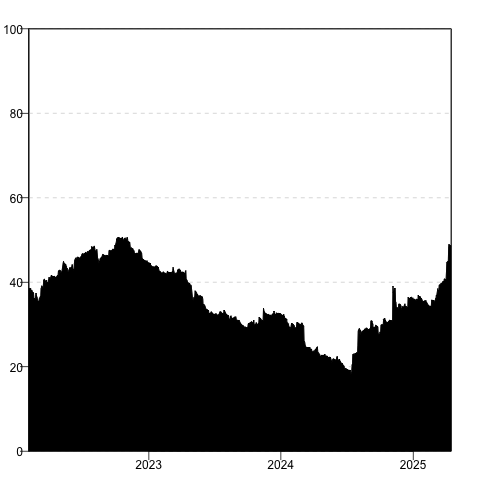

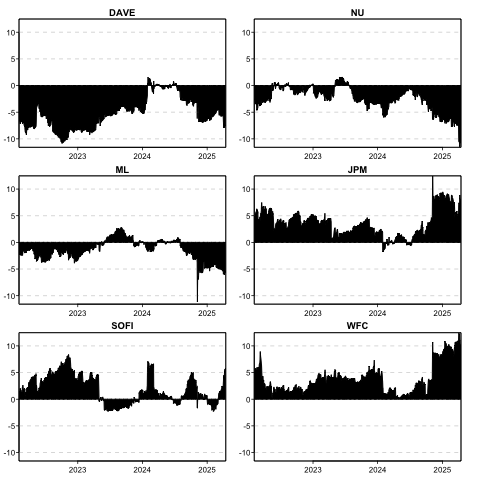

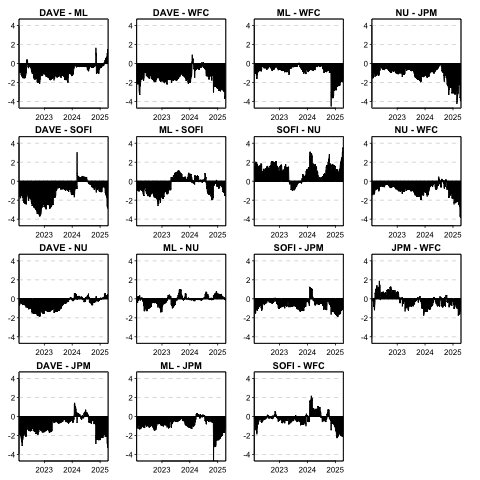

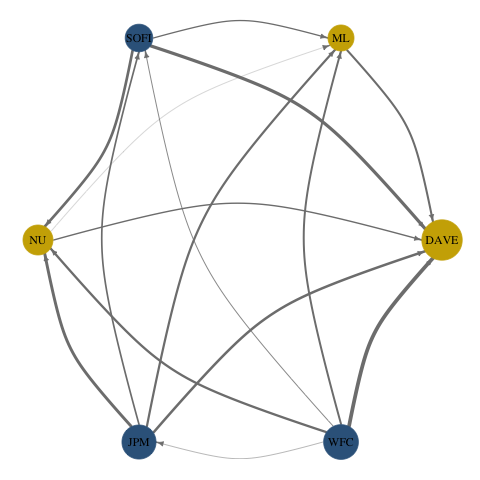

In [7]:
%%R -i asset_returns -i MIN_TVPVAR_OBS

asset_tvpvar_results <- run_tvpvar_connectedness(asset_returns, "Six-asset returns: full working sample", MIN_TVPVAR_OBS)

In [8]:
%%R

periods_r <- list(
    "1. COVID and SPAC boom" = c("2020-03-03", "2021-12-31"),
    "2. Tightening and stress" = c("2022-01-01", "2023-12-31"),
    "3. Recent period" = c("2024-01-01", "2025-05-07")
)

print("R period definitions:")
print(periods_r)

[1] "R period definitions:"
$`1. COVID and SPAC boom`
[1] "2020-03-03" "2021-12-31"

$`2. Tightening and stress`
[1] "2022-01-01" "2023-12-31"

$`3. Recent period`
[1] "2024-01-01" "2025-05-07"



[1] "Skipping Six-asset returns - 1. COVID and SPAC boom (2020-03-03 to 2021-12-31) - only 0 aligned observations; need at least 60"
[1] "#######################################################"
[1] "TVP-VAR RESULTS: Six-asset returns - 2. Tightening and stress (2022-01-01 to 2023-12-31)"
[1] "Observations: 497"
[1] "Sample: 2022-02-03 to 2023-12-29"
[1] "#######################################################"
        DAVE     ML       SOFI     NU       JPM      WFC      FROM         
DAVE    "69.69"  " 7.93"  " 8.09"  " 5.37"  " 4.14"  " 4.78"  "30.31"      
ML      " 6.43"  "66.78"  " 9.49"  " 9.89"  " 4.18"  " 3.23"  "33.22"      
SOFI    " 5.94"  " 8.96"  "59.47"  "12.30"  " 6.58"  " 6.75"  "40.53"      
NU      " 4.56"  " 9.68"  "13.27"  "61.42"  " 5.76"  " 5.31"  "38.58"      
JPM     " 3.15"  " 3.52"  " 5.94"  " 4.89"  "50.60"  "31.90"  "49.40"      
WFC     " 3.50"  " 2.89"  " 6.39"  " 4.41"  "32.02"  "50.79"  "49.21"      
TO      " 23.58" " 32.97" " 43.18" " 36.86" " 52.70" 

Estimating model
Computing connectedness measures
The TVP-VAR connectedness approach is implemented according to:
 Antonakakis, N., Chatziantoniou, I., & Gabauer, D. (2020). Refined measures of dynamic connectedness based on time-varying parameter vector autoregressions. Journal of Risk and Financial Management.
Estimating model
Computing connectedness measures
The TVP-VAR connectedness approach is implemented according to:
 Antonakakis, N., Chatziantoniou, I., & Gabauer, D. (2020). Refined measures of dynamic connectedness based on time-varying parameter vector autoregressions. Journal of Risk and Financial Management.


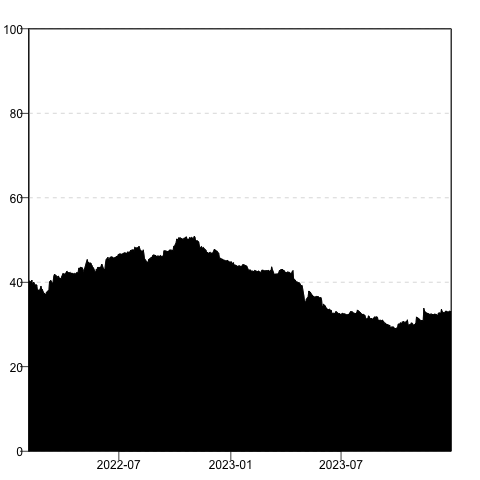

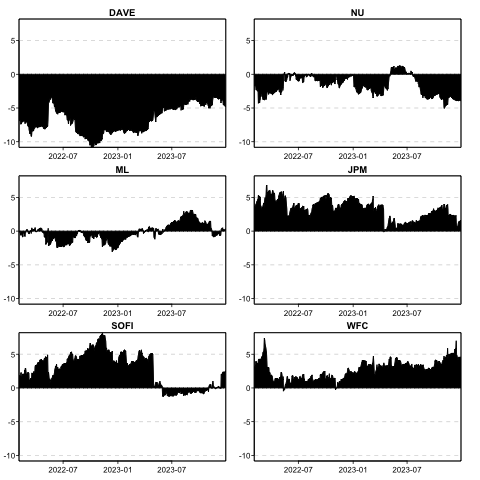

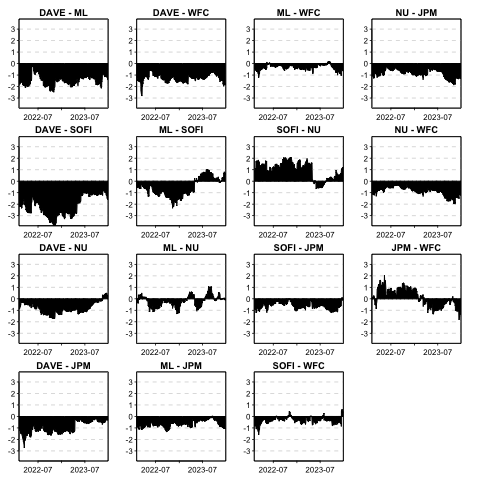

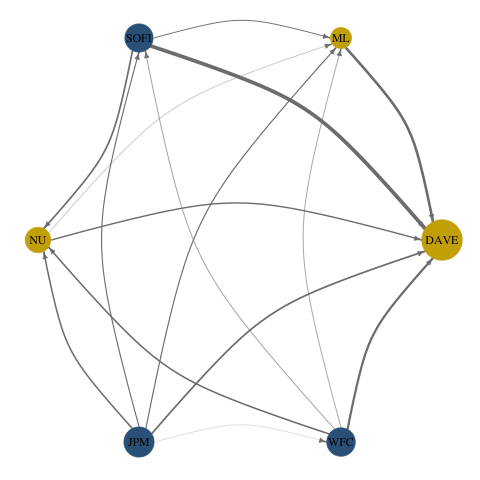

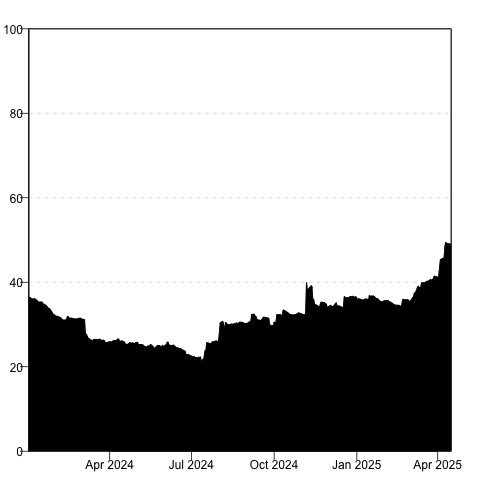

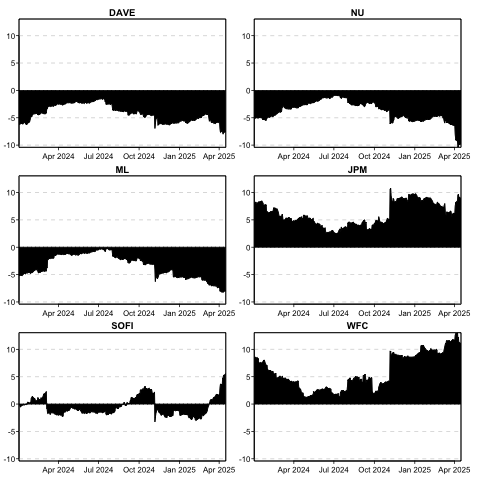

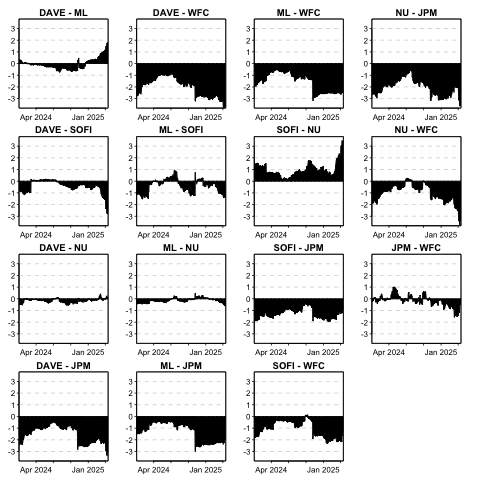

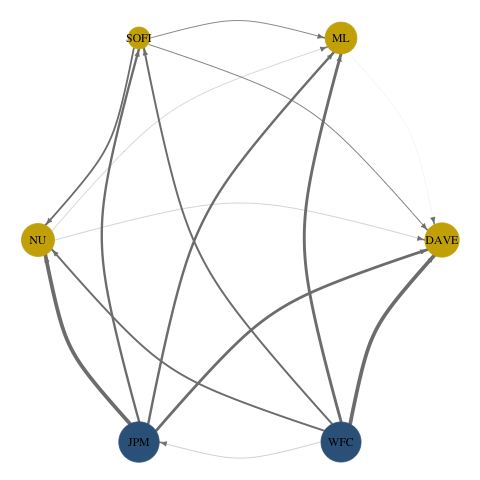

In [9]:
%%R -i asset_returns -i MIN_TVPVAR_OBS

asset_period_tvpvar_results <- run_period_tvpvar(asset_returns, "Six-asset returns", periods_r, MIN_TVPVAR_OBS)

## 6. Equal-Weighted Category Indices

,Index,Constituents,First available,Last available,Non-missing index values
0,NeoBank,"DAVE, ML",2020-08-14,2025-05-07,1229
1,Challenger,"SOFI, NU",2021-12-09,2025-05-07,888
2,Traditional,"JPM, WFC",2020-03-03,2025-05-07,1346


Equal-weighted indices preview:


,NeoBank,Challenger,Traditional
Date,,,
2020-03-03,NaN,NaN,100.0000
2020-03-04,NaN,NaN,102.3087
2020-03-05,NaN,NaN,96.7100
2020-03-06,NaN,NaN,91.9611
2020-03-09,NaN,NaN,80.0177


,NeoBank,Challenger,Traditional
Date,,,
2025-05-01,66.0124,110.0233,199.6462
2025-05-02,71.6875,111.3492,204.6848
2025-05-05,71.7080,112.1400,204.7744
2025-05-06,72.5089,111.4383,202.9196
2025-05-07,73.8165,112.3503,202.5623


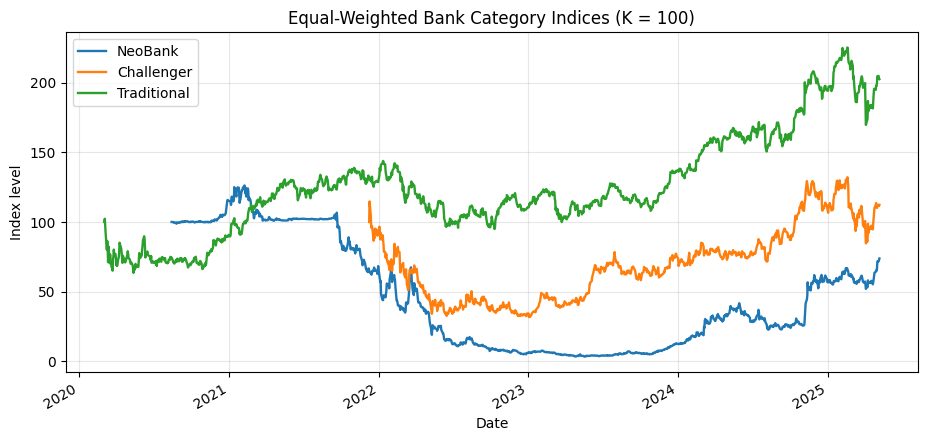

In [10]:
def calculate_equal_weighted_index(price_df: pd.DataFrame, base_value: float = 100) -> pd.Series:
    """Create an equal-weighted index from simple daily returns, rebased to base_value."""
    filled_prices = ffill_inside_observed_range(price_df)
    daily_returns = filled_prices.pct_change(fill_method=None)
    active_assets = filled_prices.notna().sum(axis=1)
    index_returns = daily_returns.mean(axis=1, skipna=True)

    valid_dates = active_assets[active_assets > 0].index
    if valid_dates.empty:
        return pd.Series(dtype=float, name="Index")

    first_valid_date = valid_dates.min()
    index_returns = index_returns.loc[first_valid_date:].copy()
    index_returns.loc[first_valid_date] = 0.0
    index_values = base_value * (1 + index_returns).cumprod()
    return index_values


index_series = {}
for group_name, tickers in INDEX_GROUPS.items():
    group_prices = asset_prices[tickers]
    index_series[group_name] = calculate_equal_weighted_index(group_prices, K).rename(group_name)

indices = pd.concat(index_series.values(), axis=1).sort_index()
indices = indices.loc[REQUESTED_START_DATE:WORKING_END_DATE]

index_availability = []
for col in indices.columns:
    valid = indices[col].dropna()
    index_availability.append(
        {
            "Index": col,
            "Constituents": ", ".join(INDEX_GROUPS[col]),
            "First available": valid.index.min().date() if not valid.empty else None,
            "Last available": valid.index.max().date() if not valid.empty else None,
            "Non-missing index values": int(valid.shape[0]),
        }
    )

display(pd.DataFrame(index_availability))

print("Equal-weighted indices preview:")
display(indices.head())
display(indices.tail())

ax = indices.plot(figsize=(11, 5), linewidth=1.7, title=f"Equal-Weighted Bank Category Indices (K = {K})")
ax.set_ylabel("Index level")
ax.grid(True, alpha=0.3)
plt.show()

### Transparent Index Rebase Comparisons

The raw index chart above is useful for auditing each index from its own first available date, but it is not a pure apples-to-apples comparison because the three lines start on different dates.

To make the chart interpretation transparent, the notebook now includes two additional comparison views:

1. **Common index-date rebase:** matches the remastered notebook's comparison style by rebasing all three category indices to `100` on the first date all three index series exist.
2. **Full-constituent rebase:** stricter robustness view that rebases all three indices to `100` on the first date every selected underlying company is available.

Rebase diagnostics:


,Chart,Base date,Rule,Transparency note
0,Common index-date rebase,2021-12-09,First date all three category index series exist,Matches the remastered notebook's comparison_d...
1,Full-constituent rebase,2022-02-02,First date every selected underlying company i...,Strictest apples-to-apples visual comparison f...


First full-constituent date by category:


,First full-constituent date
NeoBank,2021-04-26
Challenger,2022-02-02
Traditional,2020-03-03


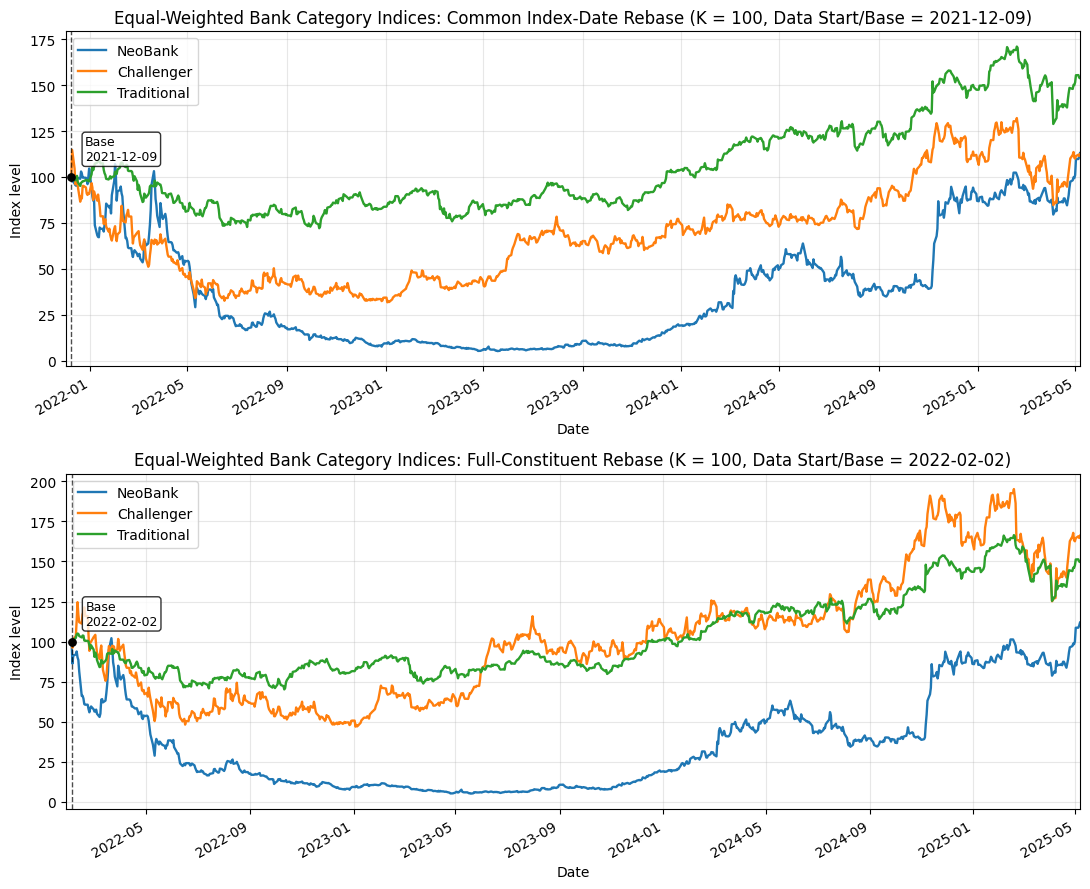

Common index-date comparison preview:


,NeoBank,Challenger,Traditional
Date,,,
2021-12-09,100.0000,100.0000,100.0000
2021-12-10,98.1981,114.7144,100.3138
2021-12-13,96.4340,104.6467,98.0789
2021-12-14,95.5707,96.0310,98.7879
2021-12-15,95.2079,96.9022,98.4690


,NeoBank,Challenger,Traditional
Date,,,
2025-05-01,101.0636,110.0233,151.5922
2025-05-02,109.7519,111.3492,155.4180
2025-05-05,109.7833,112.1400,155.4861
2025-05-06,111.0096,111.4383,154.0777
2025-05-07,113.0113,112.3503,153.8064


Full-constituent comparison preview:


,NeoBank,Challenger,Traditional
Date,,,
2022-02-02,100.0000,100.0000,100.0000
2022-02-03,86.2227,96.1434,98.9071
2022-02-04,91.2293,101.5084,101.2306
2022-02-07,91.9557,103.6101,102.2984
2022-02-08,93.8298,112.9565,104.5276


,NeoBank,Challenger,Traditional
Date,,,
2025-05-01,100.0381,162.5952,147.5330
2025-05-02,108.6383,164.5546,151.2564
2025-05-05,108.6694,165.7233,151.3226
2025-05-06,109.8832,164.6864,149.9519
2025-05-07,111.8647,166.0342,149.6879


In [11]:
# Transparent comparison charts for the equal-weighted category indices.
# These do not replace the raw index chart above; they clarify how the visual changes
# when all index lines share the same base date.

first_common_index_date = indices.dropna(how="any").index.min()

first_full_constituent_dates = {}
for group_name, tickers in INDEX_GROUPS.items():
    active_count = asset_prices[tickers].notna().sum(axis=1)
    full_dates = active_count[active_count == len(tickers)].index
    first_full_constituent_dates[group_name] = full_dates.min() if not full_dates.empty else pd.NaT

first_full_constituent_date = max(first_full_constituent_dates.values())

rebase_diagnostics = pd.DataFrame(
    [
        {
            "Chart": "Common index-date rebase",
            "Base date": first_common_index_date.date(),
            "Rule": "First date all three category index series exist",
            "Transparency note": "Matches the remastered notebook's comparison_df style; some category indices may still have only one constituent before the second stock starts.",
        },
        {
            "Chart": "Full-constituent rebase",
            "Base date": first_full_constituent_date.date(),
            "Rule": "First date every selected underlying company is available",
            "Transparency note": "Strictest apples-to-apples visual comparison for the selected six-company robustness sample.",
        },
    ]
)

print("Rebase diagnostics:")
display(rebase_diagnostics)

print("First full-constituent date by category:")
display(pd.Series(first_full_constituent_dates, name="First full-constituent date").to_frame())

comparison_common_index_date = (
    indices.loc[first_common_index_date:] / indices.loc[first_common_index_date]
) * K

comparison_full_constituent = (
    indices.loc[first_full_constituent_date:] / indices.loc[first_full_constituent_date]
) * K

import matplotlib.dates as mdates


def mark_rebase_start(ax, base_date, data, label):
    """Mark the actual rebase/start date so the two comparison charts are not visually ambiguous."""
    ax.axvline(base_date, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.scatter([base_date], [K], color="black", s=28, zorder=5)
    ax.annotate(
        f"{label}\n{base_date.date()}",
        xy=(base_date, K),
        xytext=(10, 12),
        textcoords="offset points",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "black", "alpha": 0.8},
    )
    ax.set_xlim(base_date - pd.Timedelta(days=7), data.index.max())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))


fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=False)

comparison_common_index_date.plot(ax=axes[0], linewidth=1.7)
axes[0].set_title(
    f"Equal-Weighted Bank Category Indices: Common Index-Date Rebase (K = {K}, Data Start/Base = {first_common_index_date.date()})"
)
axes[0].set_ylabel("Index level")
axes[0].grid(True, alpha=0.3)
mark_rebase_start(axes[0], first_common_index_date, comparison_common_index_date, "Base")

comparison_full_constituent.plot(ax=axes[1], linewidth=1.7)
axes[1].set_title(
    f"Equal-Weighted Bank Category Indices: Full-Constituent Rebase (K = {K}, Data Start/Base = {first_full_constituent_date.date()})"
)
axes[1].set_ylabel("Index level")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)
mark_rebase_start(axes[1], first_full_constituent_date, comparison_full_constituent, "Base")

plt.tight_layout()
plt.show()

print("Common index-date comparison preview:")
display(comparison_common_index_date.head())
display(comparison_common_index_date.tail())

print("Full-constituent comparison preview:")
display(comparison_full_constituent.head())
display(comparison_full_constituent.tail())

## 7. Index Returns, Descriptive Statistics, Unit Root Tests, and Correlations

In [12]:
index_returns_raw = calculate_returns(indices, RETURN_SCALE)
index_returns = aligned_returns(index_returns_raw, "Index returns")

print("Index returns preview:")
display(index_returns.head())
display(index_returns.tail())

index_stats = descriptive_statistics(index_returns)
index_unit_roots = run_unit_root_tests(index_returns)
index_correlation = index_returns.corr()

print("Index return descriptive statistics:")
display(index_stats)

print("Index return unit-root tests:")
display(index_unit_roots)

print("Index return correlation matrix:")
display(index_correlation)

Index returns: 887 aligned observations
Index returns aligned sample: 2021-12-10 to 2025-05-07
Index returns preview:


,NeoBank,Challenger,Traditional
Date,,,
2021-12-10,-1.8019,14.7144,0.3138
2021-12-13,-1.7965,-8.7764,-2.2279
2021-12-14,-0.8952,-8.2331,0.7229
2021-12-15,-0.3796,0.9073,-0.3228
2021-12-16,3.8516,-0.0999,2.1714


,NeoBank,Challenger,Traditional
Date,,,
2025-05-01,1.6980,-0.3620,1.0273
2025-05-02,8.5969,1.2051,2.5238
2025-05-05,0.0286,0.7102,0.0438
2025-05-06,1.1169,-0.6257,-0.9058
2025-05-07,1.8032,0.8184,-0.1761


Index return descriptive statistics:


/var/folders/0f/_zt843k12vs010rnwnmcwf9c0000gn/T/ipykernel_97150/709271408.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/var/folders/0f/_zt843k12vs010rnwnmcwf9c0000gn/T/ipykernel_97150/709271408.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/var/folders/0f/_zt843k12vs010rnwnmcwf9c0000gn/T/ipykernel_97150/709271408.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


,NeoBank,Challenger,Traditional
count,887.0000,887.0000,887.0000
mean,0.1419,0.0756,0.0623
std,5.1200,3.5473,1.6604
min,-20.0872,-12.3052,-8.0442
25%,-2.9119,-1.9085,-0.8053
50%,0.0000,0.0000,0.0058
75%,2.6269,1.9821,0.9469
max,32.4115,19.8790,12.3276
skewness,0.8273,0.3775,0.2450
kurtosis,4.5848,2.8253,5.4001


Index return unit-root tests:


,Observations,ADF statistic,ADF p-value,ADF conclusion,KPSS statistic,KPSS p-value,KPSS conclusion
Series,,,,,,,
NeoBank,887,-27.4832,0.0000,Stationary,0.9595,0.0100,Non-stationary
Challenger,887,-17.1293,0.0000,Stationary,0.3180,0.1000,Stationary
Traditional,887,-17.1369,0.0000,Stationary,0.2059,0.1000,Stationary


Index return correlation matrix:


,NeoBank,Challenger,Traditional
NeoBank,1.0000,0.4133,0.3030
Challenger,0.4133,1.0000,0.4277
Traditional,0.3030,0.4277,1.0000


## 8. Index TVP-VAR Connectedness

[1] "#######################################################"
[1] "TVP-VAR RESULTS: Three-index returns: full working sample"
[1] "Observations: 887"
[1] "Sample: 2021-12-10 to 2025-05-07"
[1] "#######################################################"
            NeoBank  Challenger Traditional FROM         
NeoBank     "80.64"  "12.76"    " 6.60"     "19.36"      
Challenger  "12.14"  "76.37"    "11.49"     "23.63"      
Traditional " 6.72"  "12.86"    "80.42"     "19.58"      
TO          "18.86"  "25.62"    "18.09"     "62.57"      
Inc.Own     " 99.51" "101.99"   " 98.51"    "cTCI/TCI"   
NET         "-0.49"  " 1.99"    "-1.49"     "31.28/20.86"
NPT         "1.00"   "2.00"     "0.00"      ""           
[1] "Plotting Total Connectedness Index (TCI)..."
[1] "Plotting Net Total Directional Connectedness (NET)..."
[1] "Plotting Net Pairwise Directional Connectedness (NPDC)..."
[1] "Plotting NPDC network..."


Estimating model
Computing connectedness measures
The TVP-VAR connectedness approach is implemented according to:
 Antonakakis, N., Chatziantoniou, I., & Gabauer, D. (2020). Refined measures of dynamic connectedness based on time-varying parameter vector autoregressions. Journal of Risk and Financial Management.


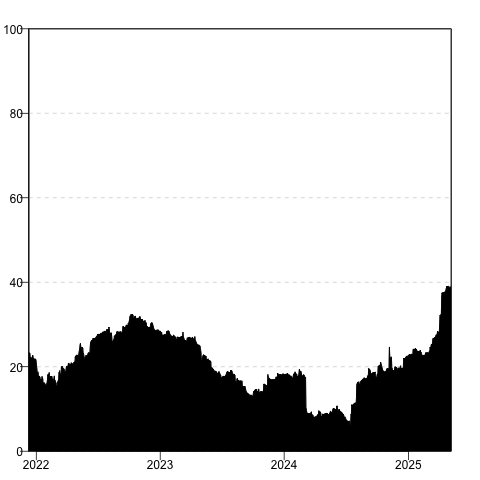

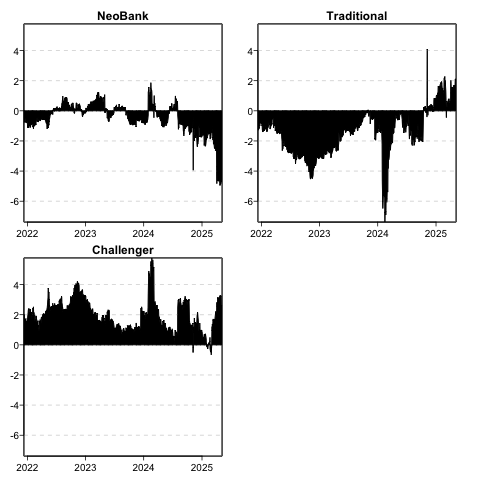

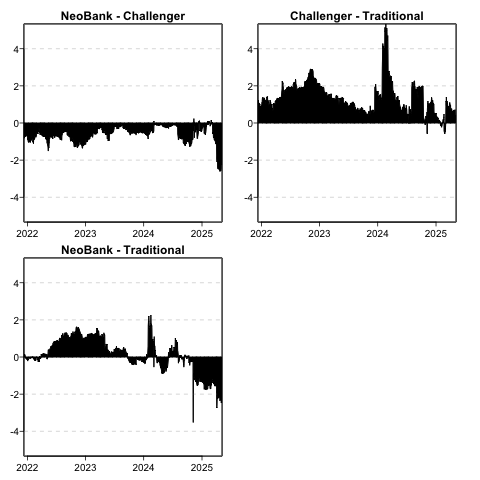

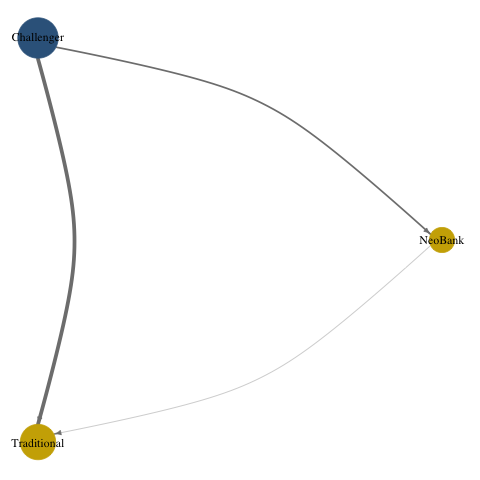

In [13]:
%%R -i index_returns -i MIN_TVPVAR_OBS

index_tvpvar_results <- run_tvpvar_connectedness(index_returns, "Three-index returns: full working sample", MIN_TVPVAR_OBS)

[1] "Skipping Three-index returns - 1. COVID and SPAC boom (2020-03-03 to 2021-12-31) - only 16 aligned observations; need at least 60"
[1] "#######################################################"
[1] "TVP-VAR RESULTS: Three-index returns - 2. Tightening and stress (2022-01-01 to 2023-12-31)"
[1] "Observations: 520"
[1] "Sample: 2022-01-03 to 2023-12-29"
[1] "#######################################################"
            NeoBank  Challenger Traditional FROM         
NeoBank     "76.77"  "16.62"    " 6.61"     "23.23"      
Challenger  "16.12"  "72.86"    "11.02"     "27.14"      
Traditional " 7.53"  "12.63"    "79.84"     "20.16"      
TO          "23.65"  "29.25"    "17.63"     "70.53"      
Inc.Own     "100.42" "102.11"   " 97.47"    "cTCI/TCI"   
NET         " 0.42"  " 2.11"    "-2.53"     "35.27/23.51"
NPT         "1.00"   "2.00"     "0.00"      ""           
[1] "Plotting Total Connectedness Index (TCI)..."
[1] "Plotting Net Total Directional Connectedness (NET)..."
[1] "P

Estimating model
Computing connectedness measures
The TVP-VAR connectedness approach is implemented according to:
 Antonakakis, N., Chatziantoniou, I., & Gabauer, D. (2020). Refined measures of dynamic connectedness based on time-varying parameter vector autoregressions. Journal of Risk and Financial Management.
Estimating model
Computing connectedness measures
The TVP-VAR connectedness approach is implemented according to:
 Antonakakis, N., Chatziantoniou, I., & Gabauer, D. (2020). Refined measures of dynamic connectedness based on time-varying parameter vector autoregressions. Journal of Risk and Financial Management.


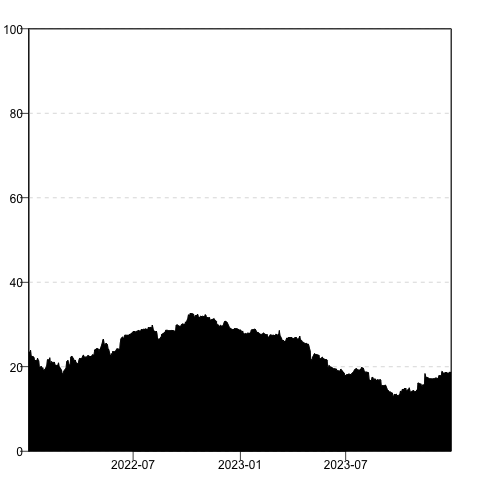

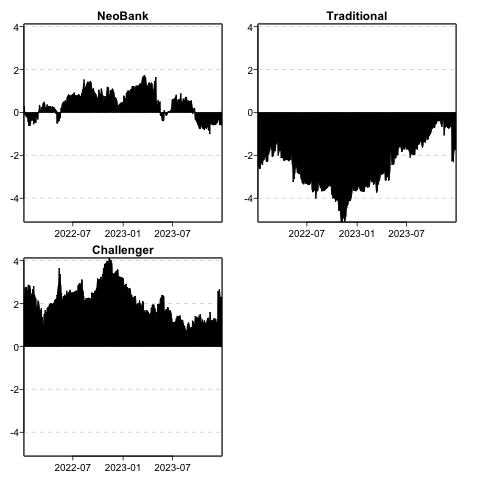

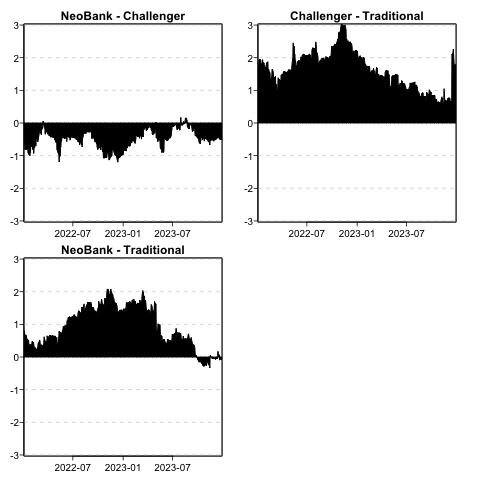

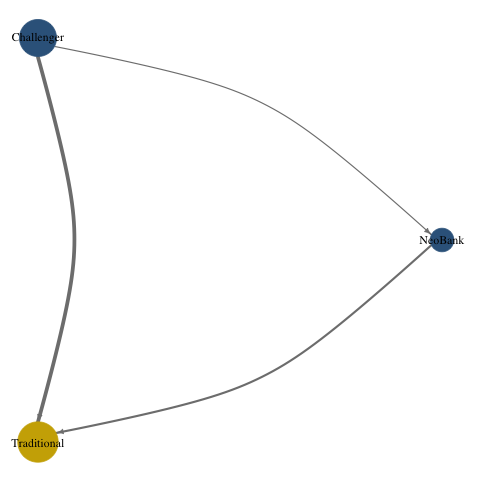

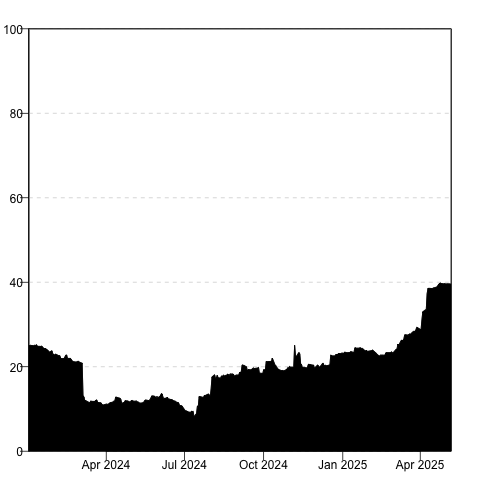

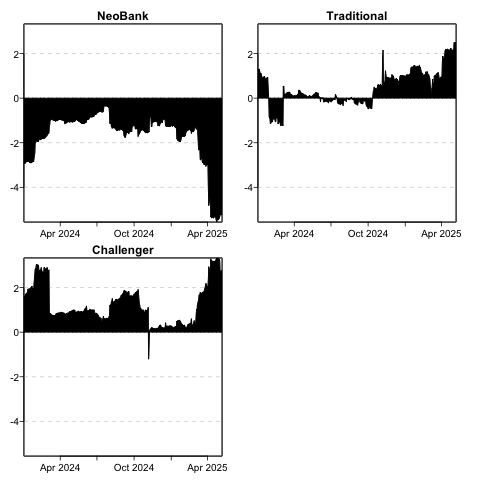

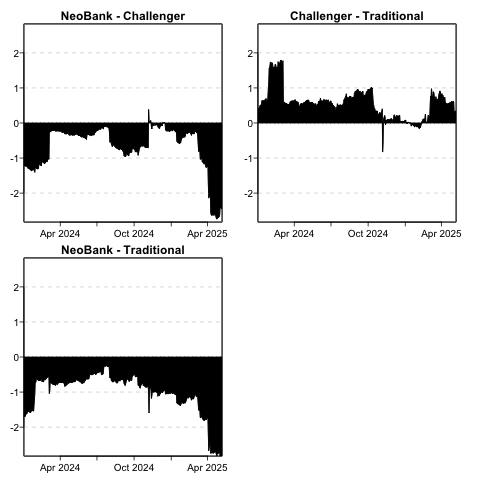

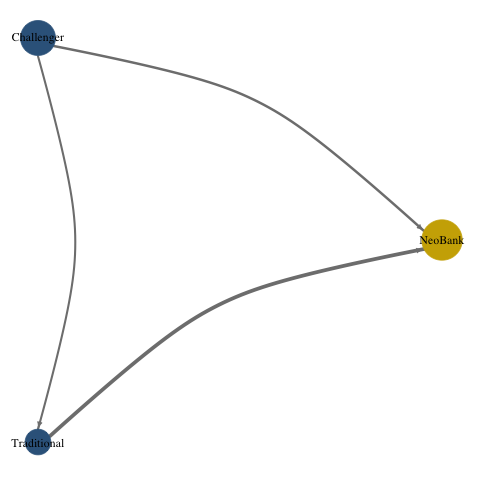

In [14]:
%%R -i index_returns -i MIN_TVPVAR_OBS

index_period_tvpvar_results <- run_period_tvpvar(index_returns, "Three-index returns", periods_r, MIN_TVPVAR_OBS)

## Final Restoration Note

To restore the exact professor-requested setup later:

1. Add or confirm `BAC` in `All Bank Data.xlsx`.
2. Extend the workbook through `2026-03-03`.
3. Replace `WFC` with `BAC` in `ASSET_MAP` and `INDEX_GROUPS`.
4. Set `WORKING_END_DATE = pd.Timestamp("2026-03-03")`.
5. Rerun the notebook from the top.